# Questão 1

A proposta original pede o uso de handel.mat, mas esse arquivo não está disponível no repositório.
Nesta implementação, a análise equivalente foi feita com [../data/handel.wav](../data/handel.wav),
aplicando compressão por DCT e reconstrução do sinal para diferentes percentuais de energia preservada.


In [3]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy.fft import dct, idct, fft, ifft, dctn, idctn
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'sosias.jpg').exists():
    PRACTICE_DIR = CWD
elif (CWD / 'pratica_4' / 'sosias.jpg').exists():
    PRACTICE_DIR = (CWD / 'pratica_4').resolve()
else:
    PRACTICE_DIR = CWD

DATA_DIR = (PRACTICE_DIR.parent / 'data').resolve()
AUDIO_PATH = DATA_DIR / 'handel.wav'
IMAGE_PATH = (PRACTICE_DIR / 'sosias.jpg').resolve()


In [4]:
def to_float_mono(signal):
    signal = np.asarray(signal)
    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    signal = signal.astype(np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    return signal


def show_audio(signal, fs, label):
    signal = np.asarray(signal, dtype=np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    display(Audio(signal, rate=fs))
    print(label)


def mse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    return float(np.mean((reference - estimate) ** 2))


def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def select_by_energy(coeffs, keep_energy):
    coeffs = np.asarray(coeffs)
    energy = np.abs(coeffs) ** 2
    flat_energy = energy.ravel()
    order = np.argsort(flat_energy)[::-1]
    cumulative = np.cumsum(flat_energy[order])
    total_energy = cumulative[-1]
    threshold = keep_energy * total_energy
    keep_count = int(np.searchsorted(cumulative, threshold, side='left')) + 1

    mask = np.zeros(coeffs.size, dtype=bool)
    mask[order[:keep_count]] = True
    mask = mask.reshape(coeffs.shape)

    compressed = np.zeros_like(coeffs)
    compressed[mask] = coeffs[mask]
    retained = float(np.sum(np.abs(compressed) ** 2) / total_energy)
    return compressed, keep_count, retained, mask


def compress_audio_dct(signal, keep_energy):
    coeffs = dct(signal, norm='ortho')
    compressed, keep_count, retained, _ = select_by_energy(coeffs, keep_energy)
    reconstructed = idct(compressed, norm='ortho')
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
    }


def compress_audio_fft(signal, keep_energy):
    coeffs = fft(signal)
    compressed, keep_count, retained, _ = select_by_energy(coeffs, keep_energy)
    reconstructed = np.real(ifft(compressed))
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
    }


def plot_time_and_error(original, reconstructed, fs, title):
    t = np.arange(len(original)) / fs
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(t, original, label='Original', alpha=0.8)
    axes[0].plot(t, reconstructed, label='Reconstruido', alpha=0.7)
    axes[0].set_title(title)
    axes[0].set_ylabel('Amplitude')
    axes[0].legend()

    axes[1].plot(t, original - reconstructed, color='tab:red')
    axes[1].set_title('Erro de reconstrução')
    axes[1].set_xlabel('Tempo (s)')
    axes[1].set_ylabel('Erro')
    plt.tight_layout()
    plt.show()


In [5]:
fs, raw_signal = wavfile.read(AUDIO_PATH)
signal = to_float_mono(raw_signal)
duration = len(signal) / fs

print(f'Taxa de amostragem: {fs} Hz')
print(f'Duração: {duration:.2f} s')
print(f'Amostras: {len(signal)}')

show_audio(signal, fs, 'Audio original: handel.wav')


Taxa de amostragem: 8192 Hz
Duração: 8.92 s
Amostras: 73113


Audio original: handel.wav


In [6]:
keep_levels = [0.995, 0.99, 0.90, 0.75, 0.50]
results = {}
rows = []

for keep in keep_levels:
    result = compress_audio_dct(signal, keep)
    reconstructed = result['reconstructed']
    key = f'{keep * 100:.1f}%'
    results[key] = result
    rows.append(
        {
            'Energia preservada': key,
            'Coeficientes mantidos': result['keep_count'],
            'Percentual de coeficientes': 100 * result['keep_count'] / len(signal),
            'Energia efetiva (%)': 100 * result['retained_energy'],
            'MSE': mse(signal, reconstructed),
        }
    )

display_rows(rows, float_digits=8)


Energia preservada | Coeficientes mantidos | Percentual de coeficientes | Energia efetiva (%) | MSE       
-------------------+-----------------------+----------------------------+---------------------+-----------
99.5%              | 40702                 | 55.66999029                | 99.50001462         | 0.00030080
99.0%              | 33683                 | 46.06978239                | 99.00000962         | 0.00060162
90.0%              | 9038                  | 12.36168670                | 90.00034190         | 0.00601602
75.0%              | 3200                  | 4.37678662                 | 75.00351185         | 0.01503845
50.0%              | 835                   | 1.14206776                 | 50.01190200         | 0.03007397


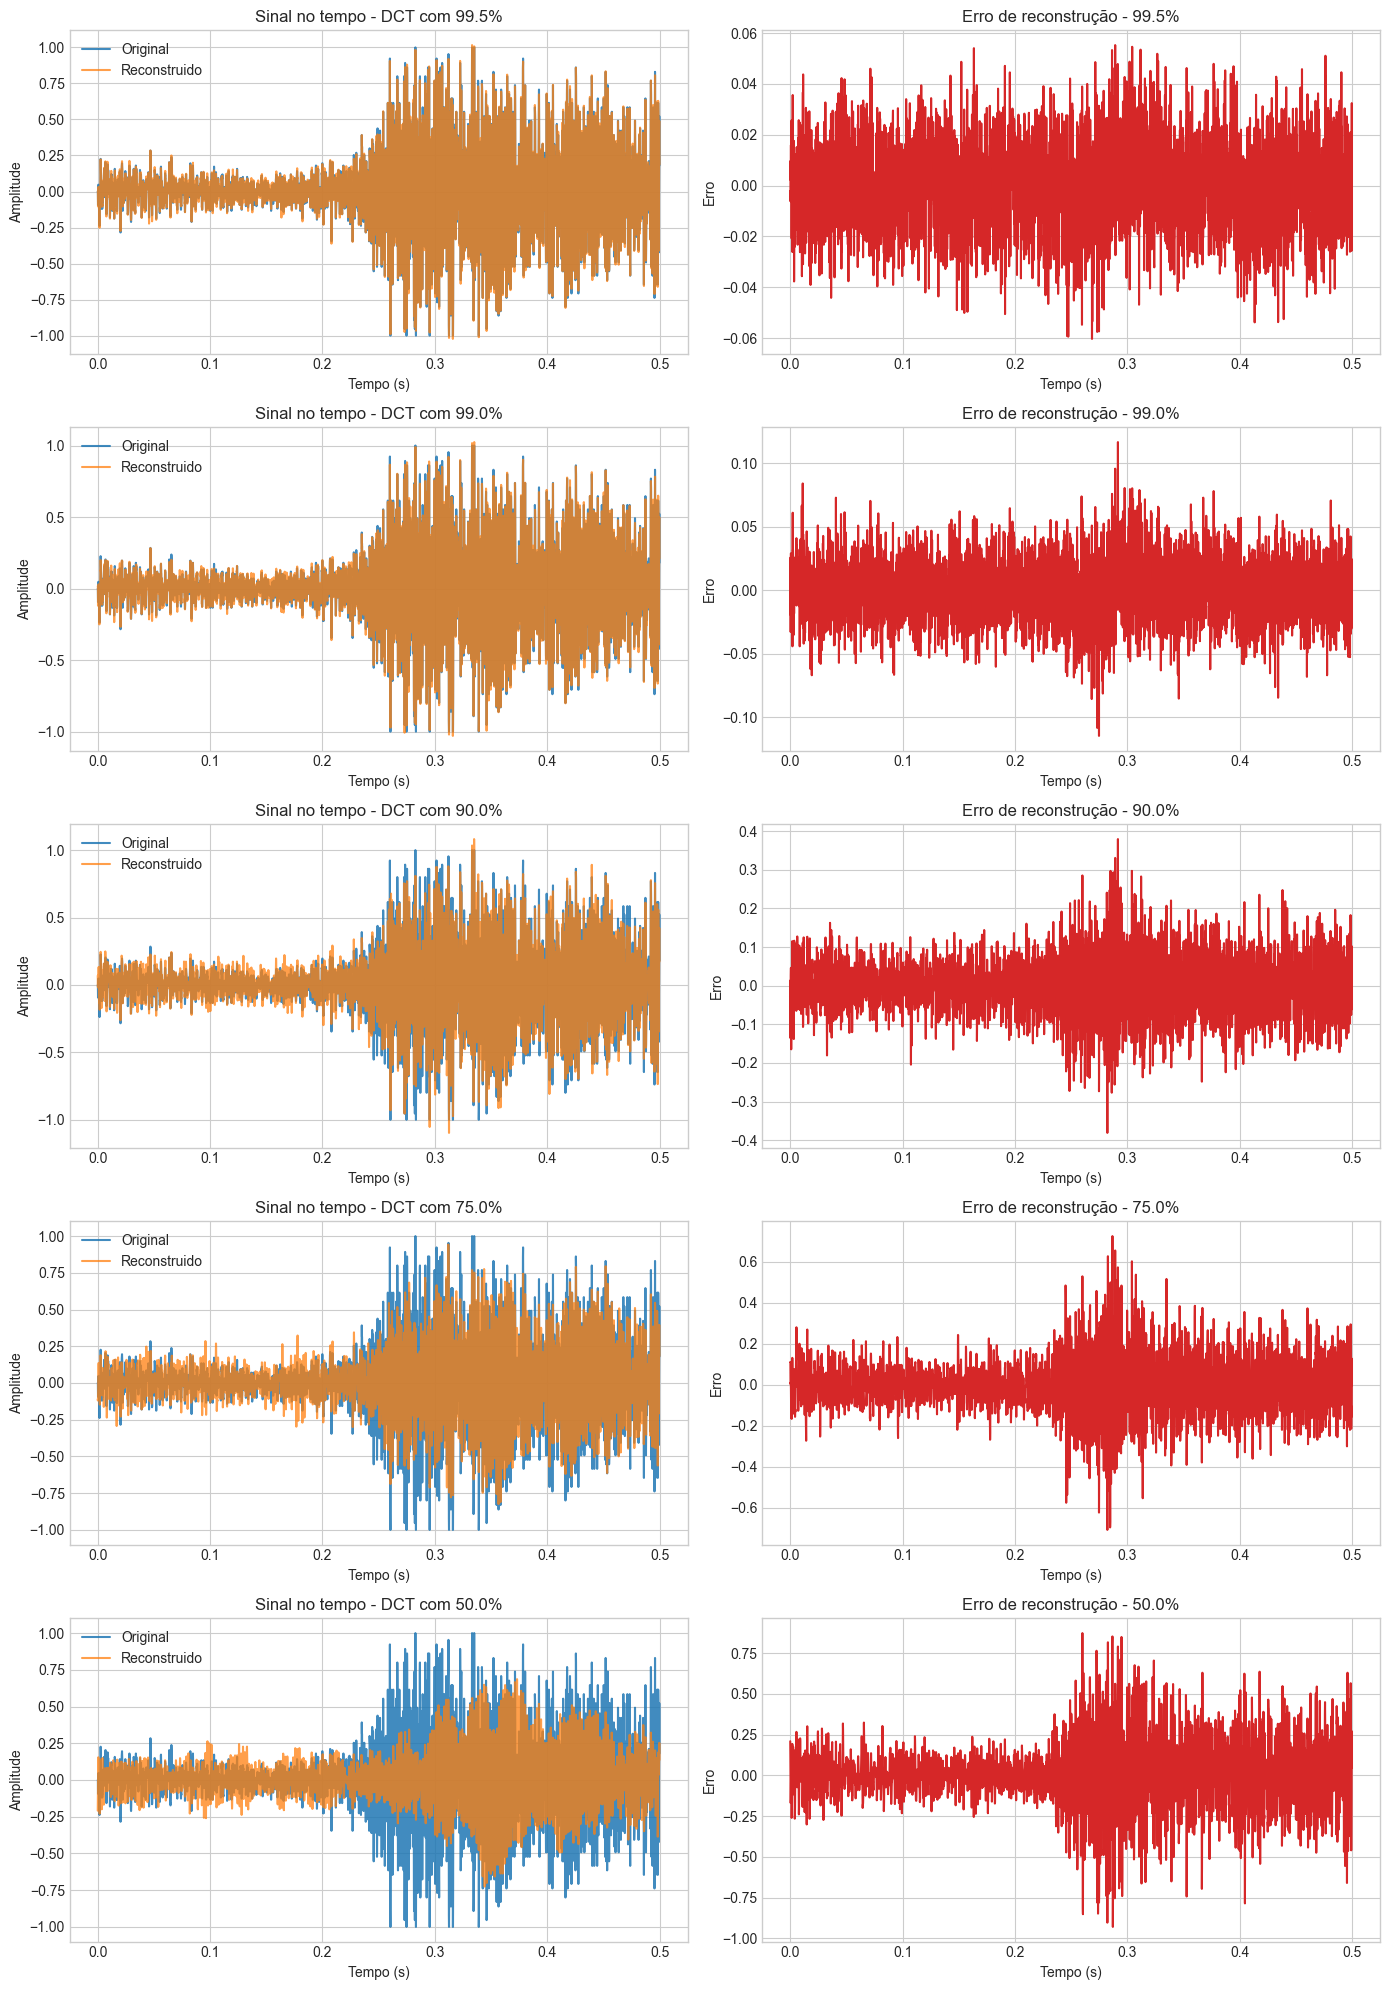

In [7]:
fig, axes = plt.subplots(len(results), 2, figsize=(14, 4 * len(results)))
time = np.arange(len(signal)) / fs
snippet = slice(0, min(len(signal), fs // 2))

for idx, (label, result) in enumerate(results.items()):
    reconstructed = result['reconstructed']

    axes[idx, 0].plot(time[snippet], signal[snippet], label='Original', alpha=0.85)
    axes[idx, 0].plot(time[snippet], reconstructed[snippet], label='Reconstruido', alpha=0.75)
    axes[idx, 0].set_title(f'Sinal no tempo - DCT com {label}')
    axes[idx, 0].set_xlabel('Tempo (s)')
    axes[idx, 0].set_ylabel('Amplitude')
    axes[idx, 0].legend()

    axes[idx, 1].plot(time[snippet], signal[snippet] - reconstructed[snippet], color='tab:red')
    axes[idx, 1].set_title(f'Erro de reconstrução - {label}')
    axes[idx, 1].set_xlabel('Tempo (s)')
    axes[idx, 1].set_ylabel('Erro')

plt.tight_layout()
plt.show()


In [8]:
for label, result in results.items():
    show_audio(result['reconstructed'], fs, f'Audio reconstruido com DCT preservando {label} de energia')


Audio reconstruido com DCT preservando 99.5% de energia


Audio reconstruido com DCT preservando 99.0% de energia


Audio reconstruido com DCT preservando 90.0% de energia


Audio reconstruido com DCT preservando 75.0% de energia


Audio reconstruido com DCT preservando 50.0% de energia


## Comentários

- A DCT concentra grande parte da energia do sinal de áudio em poucos coeficientes.
- Para níveis altos de preservação de energia, a reconstrução permanece muito próxima do original.
- À medida que a taxa de compressão aumenta, o erro cresce e o áudio perde detalhes finos.
